In [65]:
import numpy as np
import matplotlib.pyplot as plt


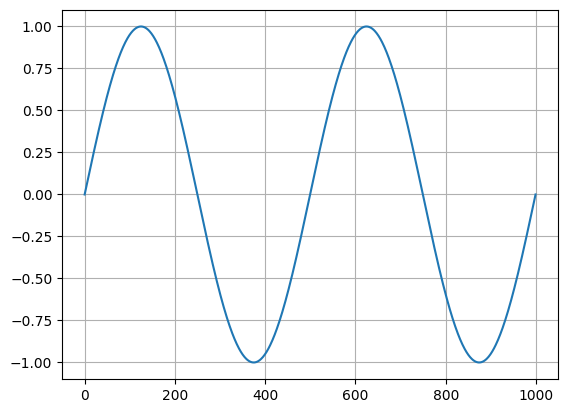

In [66]:
# sine signal convolution

f=2
n=np.linspace(-1,1,1000)
signal=np.sin(2*np.pi*n)



plt.grid(True)
plt.plot(signal)
# plt.stem(n,signal)
plt.show()

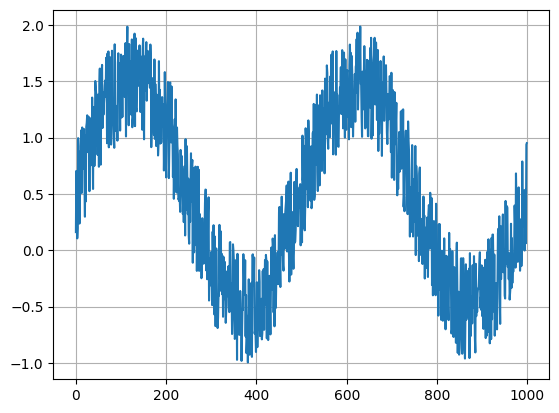

In [67]:
noise=np.random.random(1000)

noisy_signal=signal+noise

# print(noisy_signal.shape)

plt.grid(True)
plt.plot(noisy_signal)
# plt.stem(n,noisy_signal)
plt.show()

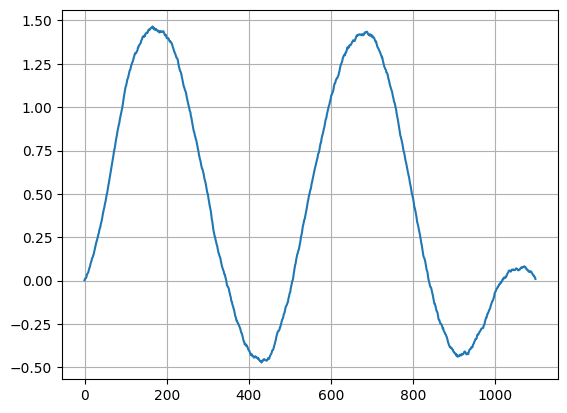

In [68]:
filtered=np.ones(100)/100

y_n=np.convolve(noisy_signal,filtered)
# print(y_n.shape)

plt.grid(True)
plt.plot(y_n)
plt.show()

[1 1 1 1 0 0 0 0 0] [ 0  0  0  0  4  8  9 10  0  0  0  0] 3 1
[np.int64(0), np.int64(4), np.int64(12), np.int64(21), np.int64(31), np.int64(27), np.int64(19), np.int64(10), np.int64(0)] [-1, 0, 1, 2, 3, 4, 5, 6, 7]


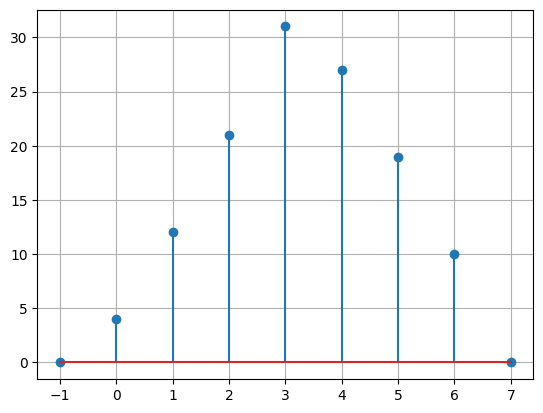

In [69]:
x_n=np.array([4,8,9,10])
lenx=len(x_n)
x0=0

h_n=np.array([1,1,1,1])
h0=0
length=len(x_n)+len(h_n)-1

h_n=h_n[::-1]
h0=len(h_n)-1-h0

ls=0

for i in range(len(h_n)):
    x_n=np.insert(x_n,0,0)

for i in range(len(h_n)):
    x_n=np.append(x_n,0)

for i in range(h0,lenx):
    h_n=np.append(h_n,0)
    ls+=1
    
for i in range(lenx):
    h_n=np.append(h_n,0)


print(h_n,x_n,h0,ls)




t=[]
y_n=[]
for i in range(length+2):
    y_n.append(0)
    t.append(i-ls)
    for j in range(len(h_n)):
        y_n[-1]+=x_n[j]*h_n[j]
    
    h_n=h_n[:-1]
    h_n=np.insert(h_n,0,0)
    h0+=1

print(y_n,t)

plt.stem(t,y_n)
plt.grid(True)
plt.show()


In [ ]:
def convolution(x,x0,h,h0):
    t=[]
    y=[]
    # y(n)= sum(k=-inf to inf) x(k)*y(-k+n)
    mx=max(len(x),len(h))
    end=len(x)+len(h)-1
    for n in range(-mx,mx+end):
        y.append(0)
        t.append(n)
        for k in range(-mx,mx+end):
            try:                       # if positive index exist?
                if k>=(-x0): a=x[k+x0] # if negative index exists?
                else: a=0
            except: a=0
            
            try:    
                if (-k+n)>=(-h0): b=h[-k+h0+n]
                else: b=0
            except: b=0
            
            y[-1]+=a*b
        
    return t,y

([-4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(4), np.int64(12), np.int64(21), np.int64(31), np.int64(27), np.int64(19), np.int64(10), np.int64(0), np.int64(0), np.int64(0), np.int64(0)])


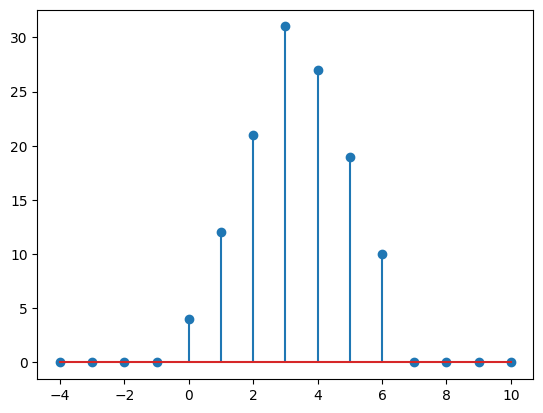

In [71]:
x_n=np.array([4,8,9,10])
x0=0

h_n=np.array([1,1,1,1])
h0=0

val=convolution(x_n,x0,h_n,h0)
print(val)

plt.stem(val[0],val[1])
plt.show()